The Project Title is:
Flight Ticket Price Prediction.

Problem Statement:
Flight ticket prices are highly dynamic and fluctuate based on numerous factors such as airline, source and destination cities, departure time, number of stops, duration of the flight, days left until departure, and travel class. Passengers often struggle to determine the right time to book tickets, while airlines need intelligent pricing strategies to maximize revenue.
The goal of this project is to build a machine learning regression model that can accurately predict the price of a flight ticket based on flight-related features. This model will help travelers make informed booking decisions and assist travel platforms in providing fare forecasting tools to improve user experience and planning.

Business Objective:
The primary business objective is to build a predictive model capable of estimating flight ticket prices using historical flight data. The model should identify the most influential factors affecting airfare and provide reliable price predictions that can assist customers, travel agencies, and airline companies in making data-driven decisions.

In [1]:
# Step-2:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df=pd.read_csv("/content/Clean_Dataset.csv",nrows=50000)
df

,Unnamed: 0,airline,flight,source_city,departure_time,stops,arrival_time,destination_city,class,duration,days_left,price
0,0,SpiceJet,SG-8709,Delhi,Evening,zero,Night,Mumbai,Economy,2.17,1,5953
1,1,SpiceJet,SG-8157,Delhi,Early_Morning,zero,Morning,Mumbai,Economy,2.33,1,5953
2,2,AirAsia,I5-764,Delhi,Early_Morning,zero,Early_Morning,Mumbai,Economy,2.17,1,5956
3,3,Vistara,UK-995,Delhi,Morning,zero,Afternoon,Mumbai,Economy,2.25,1,5955
4,4,Vistara,UK-963,Delhi,Morning,zero,Morning,Mumbai,Economy,2.33,1,5955
...,...,...,...,...,...,...,...,...,...,...,...,...
49995,49995,Vistara,UK-877,Mumbai,Morning,one,Afternoon,Delhi,Economy,4.92,36,5232
49996,49996,Vistara,UK-873,Mumbai,Early_Morning,one,Afternoon,Delhi,Economy,6.33,36,5232
49997,49997,Vistara,UK-873,Mumbai,Early_Morning,one,Afternoon,Delhi,Economy,9.33,36,5232
49998,49998,Vistara,UK-875,Mumbai,Evening,one,Night,Delhi,Economy,27.50,36,5232


In [3]:
df.head()

,Unnamed: 0,airline,flight,source_city,departure_time,stops,arrival_time,destination_city,class,duration,days_left,price
0,0,SpiceJet,SG-8709,Delhi,Evening,zero,Night,Mumbai,Economy,2.17,1,5953
1,1,SpiceJet,SG-8157,Delhi,Early_Morning,zero,Morning,Mumbai,Economy,2.33,1,5953
2,2,AirAsia,I5-764,Delhi,Early_Morning,zero,Early_Morning,Mumbai,Economy,2.17,1,5956
3,3,Vistara,UK-995,Delhi,Morning,zero,Afternoon,Mumbai,Economy,2.25,1,5955
4,4,Vistara,UK-963,Delhi,Morning,zero,Morning,Mumbai,Economy,2.33,1,5955


In [4]:
df.tail()

,Unnamed: 0,airline,flight,source_city,departure_time,stops,arrival_time,destination_city,class,duration,days_left,price
49995,49995,Vistara,UK-877,Mumbai,Morning,one,Afternoon,Delhi,Economy,4.92,36,5232
49996,49996,Vistara,UK-873,Mumbai,Early_Morning,one,Afternoon,Delhi,Economy,6.33,36,5232
49997,49997,Vistara,UK-873,Mumbai,Early_Morning,one,Afternoon,Delhi,Economy,9.33,36,5232
49998,49998,Vistara,UK-875,Mumbai,Evening,one,Night,Delhi,Economy,27.50,36,5232
49999,49999,Vistara,UK-825,Mumbai,Morning,one,Night,Delhi,Economy,14.17,36,5343


In [5]:
df.shape

(50000, 12)

In [6]:
df.columns

Index(['Unnamed: 0', 'airline', 'flight', 'source_city', 'departure_time',
       'stops', 'arrival_time', 'destination_city', 'class', 'duration',
       'days_left', 'price'],
      dtype='object')

In [7]:
df.dtypes

,0
Unnamed: 0,int64
airline,object
flight,object
source_city,object
departure_time,object
stops,object
arrival_time,object
destination_city,object
class,object
duration,float64


In [8]:
# Step-3:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 12 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Unnamed: 0        50000 non-null  int64  
 1   airline           50000 non-null  object 
 2   flight            50000 non-null  object 
 3   source_city       50000 non-null  object 
 4   departure_time    50000 non-null  object 
 5   stops             50000 non-null  object 
 6   arrival_time      50000 non-null  object 
 7   destination_city  50000 non-null  object 
 8   class             50000 non-null  object 
 9   duration          50000 non-null  float64
 10  days_left         50000 non-null  int64  
 11  price             50000 non-null  int64  
dtypes: float64(1), int64(3), object(8)
memory usage: 4.6+ MB


-->This is a regression problem.

In [9]:
df.columns.tolist()

['Unnamed: 0',
 'airline',
 'flight',
 'source_city',
 'departure_time',
 'stops',
 'arrival_time',
 'destination_city',
 'class',
 'duration',
 'days_left',
 'price']

In [10]:
df.dtypes

,0
Unnamed: 0,int64
airline,object
flight,object
source_city,object
departure_time,object
stops,object
arrival_time,object
destination_city,object
class,object
duration,float64


In [11]:
df.isnull().sum()

,0
Unnamed: 0,0
airline,0
flight,0
source_city,0
departure_time,0
stops,0
arrival_time,0
destination_city,0
class,0
duration,0


In [12]:
df.duplicated().sum()

np.int64(0)

In [13]:
df.describe()

,Unnamed: 0,duration,days_left,price
count,50000.000000,50000.000000,50000.000000,50000.000000
mean,24999.500000,10.666235,25.192280,6315.645560
std,14433.901067,7.136376,13.321391,3710.349164
min,0.000000,1.830000,1.000000,1998.000000
25%,12499.750000,5.330000,14.000000,3999.000000
50%,24999.500000,9.170000,25.000000,5549.000000
75%,37499.250000,14.500000,36.000000,7425.000000
max,49999.000000,39.670000,49.000000,35145.000000


In [14]:
df.describe(include='all')

,Unnamed: 0,airline,flight,source_city,departure_time,stops,arrival_time,destination_city,class,duration,days_left,price
count,50000.000000,50000,50000,50000,50000,50000,50000,50000,50000,50000.000000,50000.000000,50000.000000
unique,NaN,6,644,2,6,3,6,6,1,NaN,NaN,NaN
top,NaN,Vistara,UK-995,Delhi,Evening,one,Night,Bangalore,Economy,NaN,NaN,NaN
freq,NaN,14356,514,43027,12649,38319,14727,10144,50000,NaN,NaN,NaN
mean,24999.500000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,10.666235,25.192280,6315.645560
std,14433.901067,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,7.136376,13.321391,3710.349164
min,0.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.830000,1.000000,1998.000000
25%,12499.750000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,5.330000,14.000000,3999.000000
50%,24999.500000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,9.170000,25.000000,5549.000000
75%,37499.250000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,14.500000,36.000000,7425.000000


In [15]:
#Numerical Features:
df.select_dtypes(include=['int64','float64']).columns

Index(['Unnamed: 0', 'duration', 'days_left', 'price'], dtype='object')

In [16]:
#Categorical Features:
df.select_dtypes(include=['object']).columns

Index(['airline', 'flight', 'source_city', 'departure_time', 'stops',
       'arrival_time', 'destination_city', 'class'],
      dtype='object')

-->Continuous variable is 'Duration'.

-->Discrete variable is 'days_left'.

-->Target variable is 'Price'.

In [17]:
df['price'].dtype

dtype('int64')

In [18]:
df.nunique()

,0
Unnamed: 0,50000
airline,6
flight,644
source_city,2
departure_time,6
stops,3
arrival_time,6
destination_city,6
class,1
duration,344


In [19]:
# Step-4:
df.mean(numeric_only=True)

,0
Unnamed: 0,24999.500000
duration,10.666235
days_left,25.192280
price,6315.645560


Observation:

-->Calculates the average value of each numerical feature.

-->Helps understand the central tendency.

Insight:

-->The average flight price gives an estimate of the overall airfare.

-->The average flight duration indicates the typical travel time.

In [20]:
df.median(numeric_only=True)

,0
Unnamed: 0,24999.50
duration,9.17
days_left,25.00
price,5549.00


Observation:
Less affected by outliers than the mean.

Insight:
If the mean is much higher than the median, the data is positively skewed.

In [21]:
df.mode().head()

,Unnamed: 0,airline,flight,source_city,departure_time,stops,arrival_time,destination_city,class,duration,days_left,price
0,0,Vistara,UK-995,Delhi,Evening,one,Night,Bangalore,Economy,2.17,18.0,5955.0
1,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,3,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,4,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


Insight:
Helps identify the most common airline, departure time, travel class.

In [22]:
df.std(numeric_only=True)

,0
Unnamed: 0,14433.901067
duration,7.136376
days_left,13.321391
price,3710.349164


Insight:
A higher standard deviation in price indicates significant variation in ticket prices.

In [23]:
df.describe(percentiles=[0.25,0.5,0.75,0.90,0.95,0.99])

,Unnamed: 0,duration,days_left,price
count,50000.000000,50000.000000,50000.000000,50000.000000
mean,24999.500000,10.666235,25.192280,6315.645560
std,14433.901067,7.136376,13.321391,3710.349164
min,0.000000,1.830000,1.000000,1998.000000
25%,12499.750000,5.330000,14.000000,3999.000000
50%,24999.500000,9.170000,25.000000,5549.000000
75%,37499.250000,14.500000,36.000000,7425.000000
90%,44999.100000,22.920000,44.000000,11520.000000
95%,47499.050000,25.670000,47.000000,13818.000000
99%,49499.010000,28.080000,49.000000,19593.000000


Insight:
Useful for identifying extreme values and understanding data distribution.

In [24]:
df.corr(numeric_only=True)

,Unnamed: 0,duration,days_left,price
Unnamed: 0,1.000000,0.041001,0.076880,-0.073948
duration,0.041001,1.000000,-0.017646,0.275994
days_left,0.076880,-0.017646,1.000000,-0.550492
price,-0.073948,0.275994,-0.550492,1.000000


Insight:

* Positive correlation means both variables increase together.

*  Negative correlation means one increases while the other decreases.


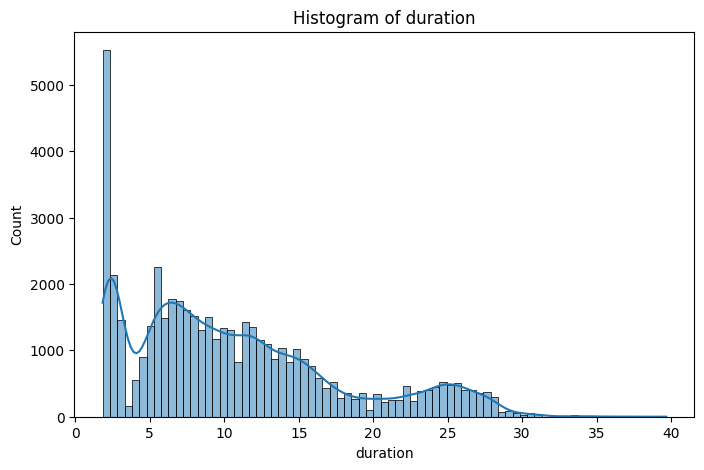

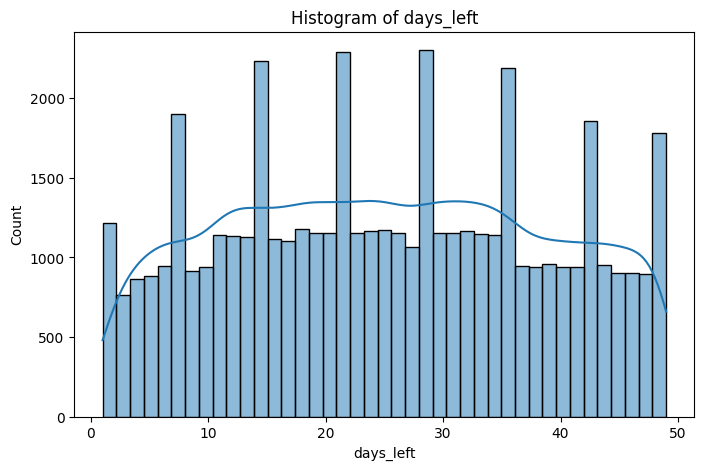

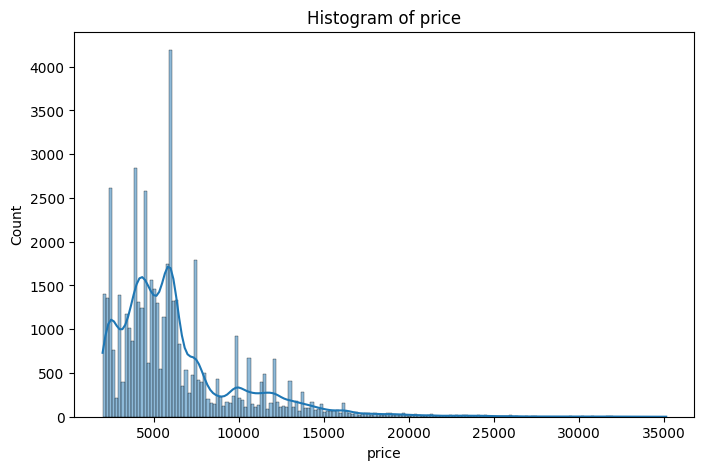

In [25]:
#Univariate Analysis:
#Histogram:
numerical_features = ['duration','days_left','price']
for column in numerical_features:
    plt.figure(figsize=(8,5))
    sns.histplot(df[column], kde=True)
    plt.title(f'Histogram of {column}')
    plt.show()

Insights:

* Price distribution may be right-skewed.

* Duration may also have skewness.

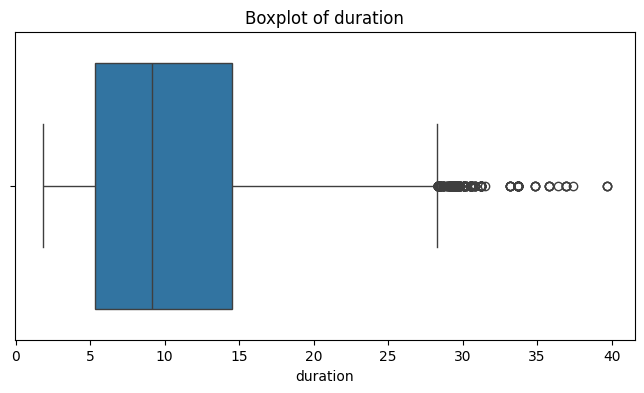

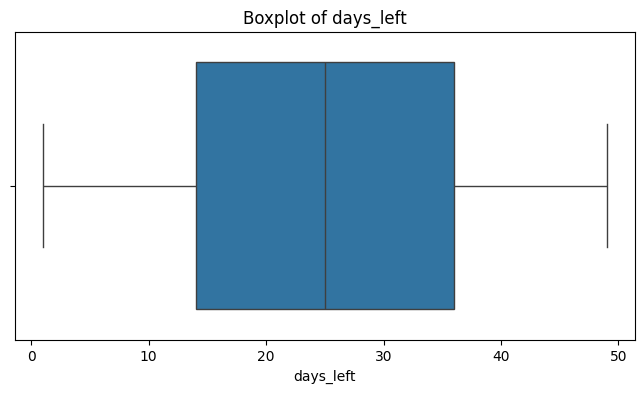

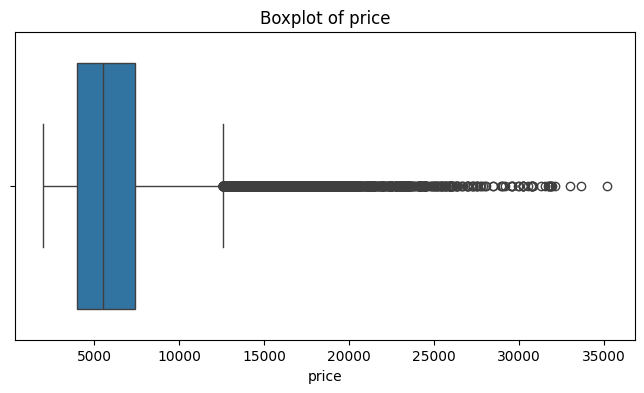

In [26]:
#Boxplot:
for column in numerical_features:
    plt.figure(figsize=(8,4))
    sns.boxplot(x=df[column])
    plt.title(f'Boxplot of {column}')
    plt.show()

Insight:

* Flight prices may contain premium-class tickets appearing as outliers.

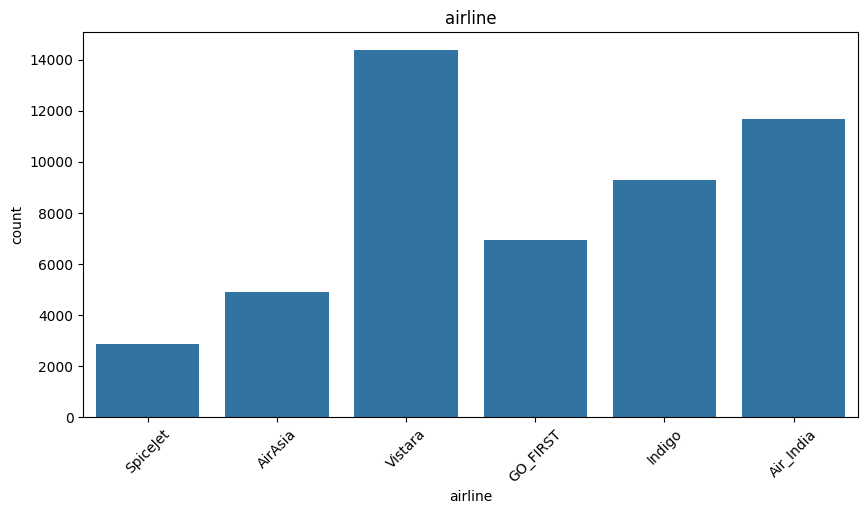

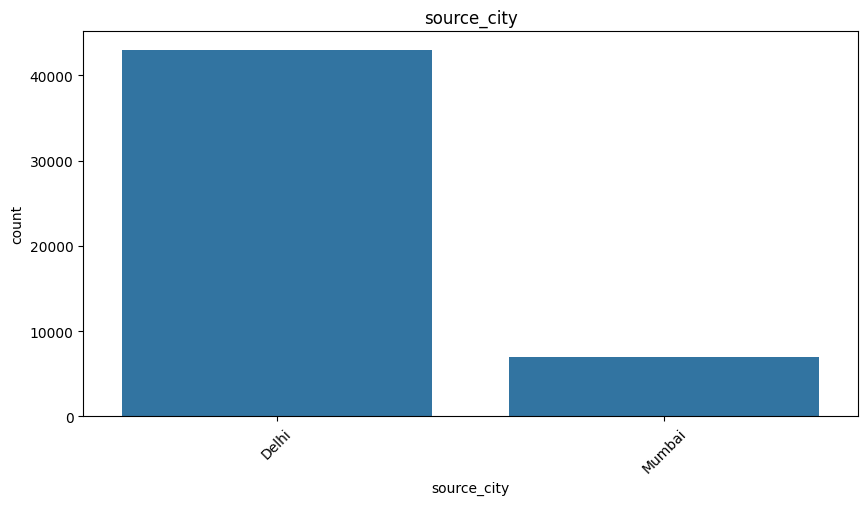

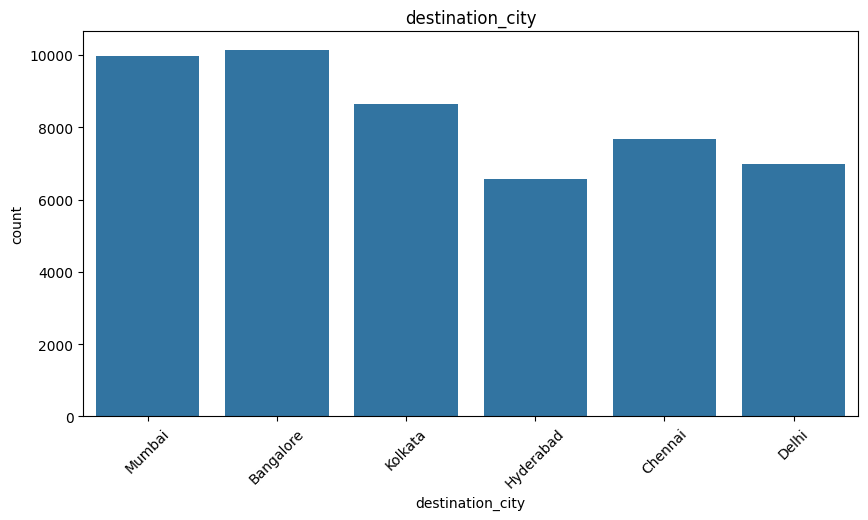

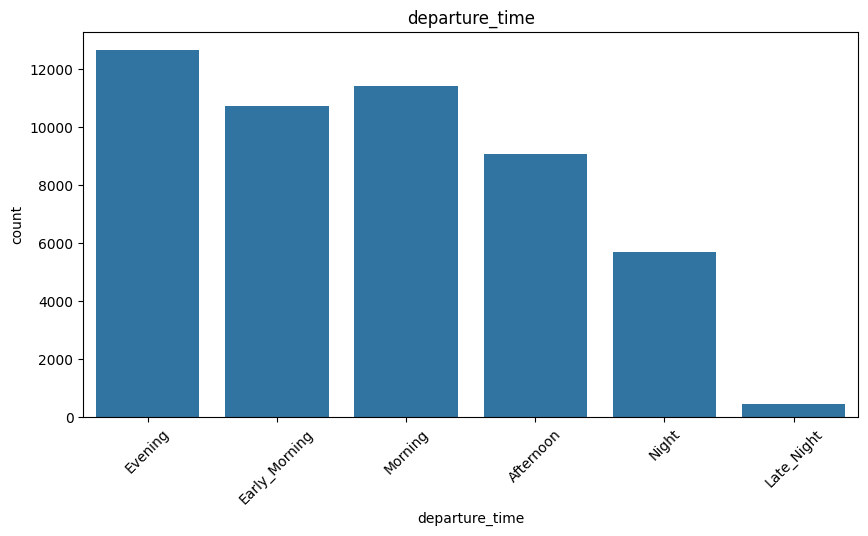

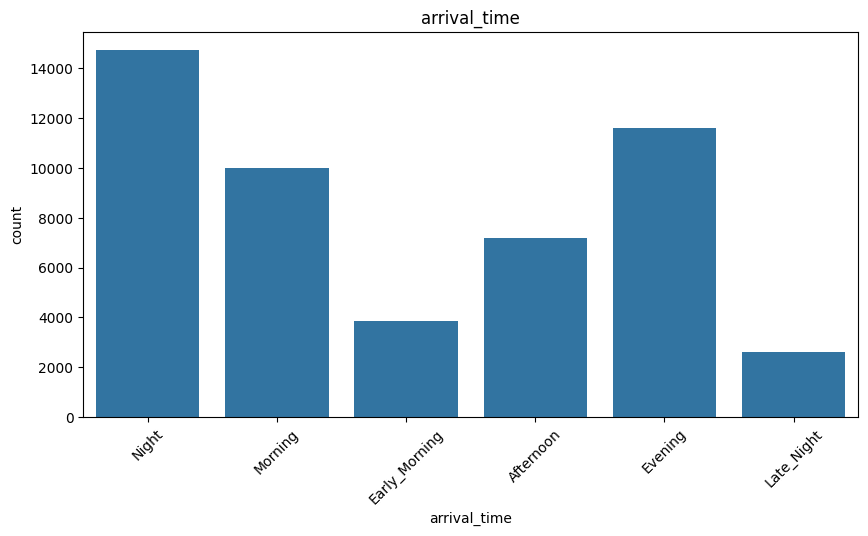

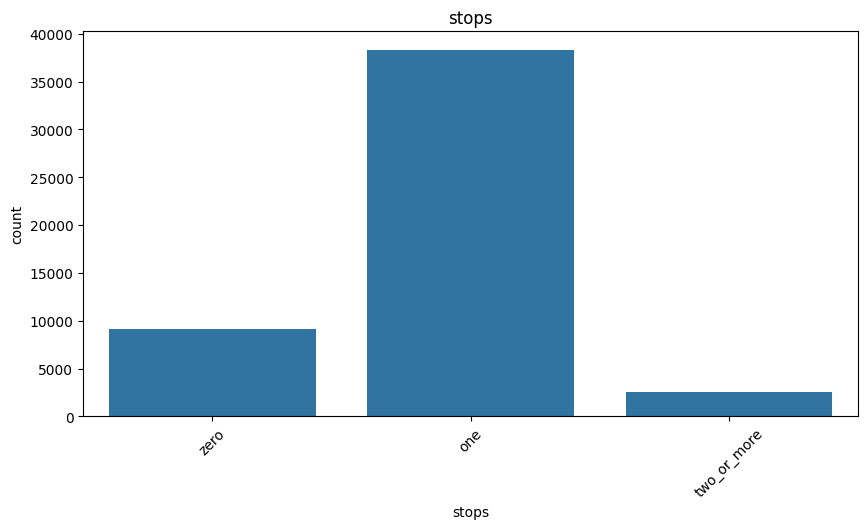

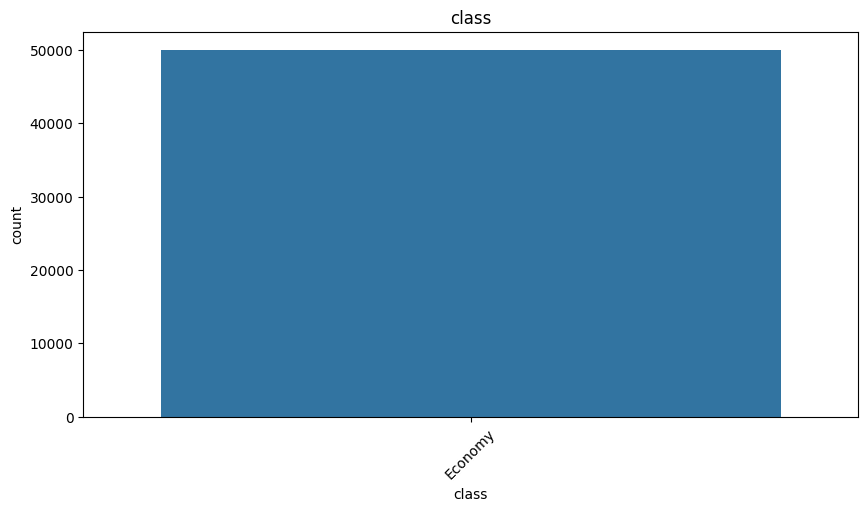

In [27]:
#Countplot:
categorical_features = ['airline','source_city','destination_city','departure_time','arrival_time','stops','class']
for column in categorical_features:
    plt.figure(figsize=(10,5))
    sns.countplot(data=df,x=column)
    plt.xticks(rotation=45)
    plt.title(column)
    plt.show()

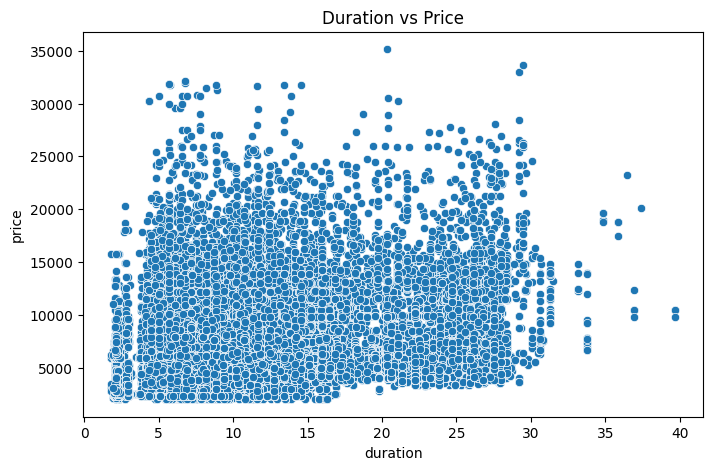

In [28]:
#Bivariate Analysis:
#Scatterplot:
plt.figure(figsize=(8,5))
sns.scatterplot(data=df,x='duration',y='price')
plt.title("Duration vs Price")
plt.show()

Insight:
* Longer flights generally tend to have higher ticket prices.

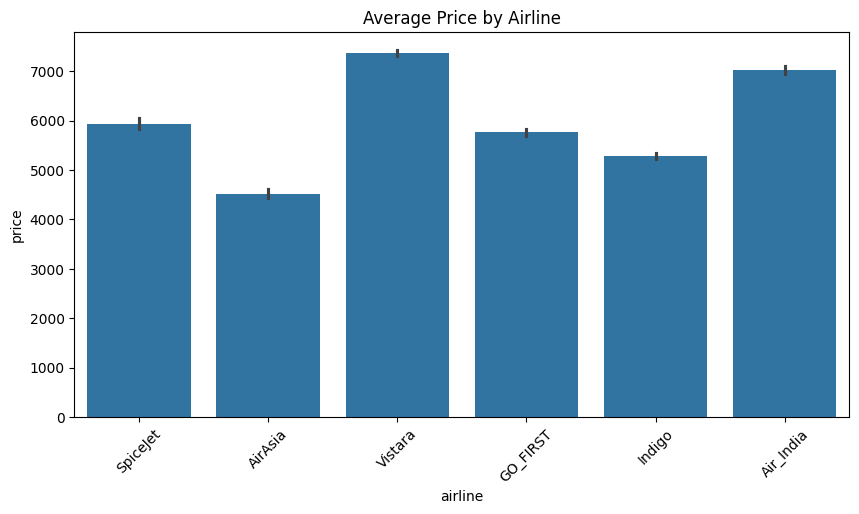

In [29]:
#Barplot:
plt.figure(figsize=(10,5))
sns.barplot(data=df,x='airline',y='price')
plt.xticks(rotation=45)
plt.title("Average Price by Airline")
plt.show()

Insight:

* Premium airlines generally charge higher fares.

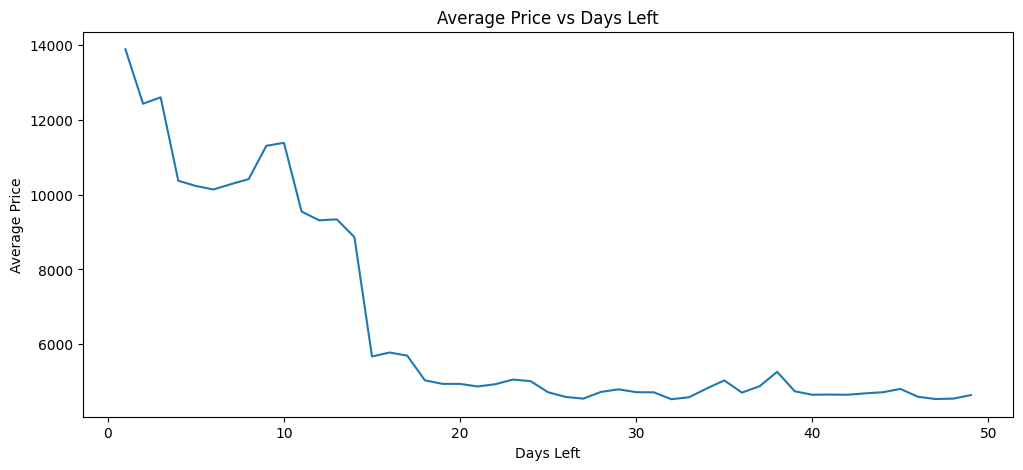

In [30]:
#Lineplot:
avg_price = df.groupby('days_left')['price'].mean()
plt.figure(figsize=(12,5))
plt.plot(avg_price)
plt.title("Average Price vs Days Left")
plt.xlabel("Days Left")
plt.ylabel("Average Price")
plt.show()

In [31]:
correlation = df.select_dtypes(include=['number']).corr()
correlation

,Unnamed: 0,duration,days_left,price
Unnamed: 0,1.000000,0.041001,0.076880,-0.073948
duration,0.041001,1.000000,-0.017646,0.275994
days_left,0.076880,-0.017646,1.000000,-0.550492
price,-0.073948,0.275994,-0.550492,1.000000


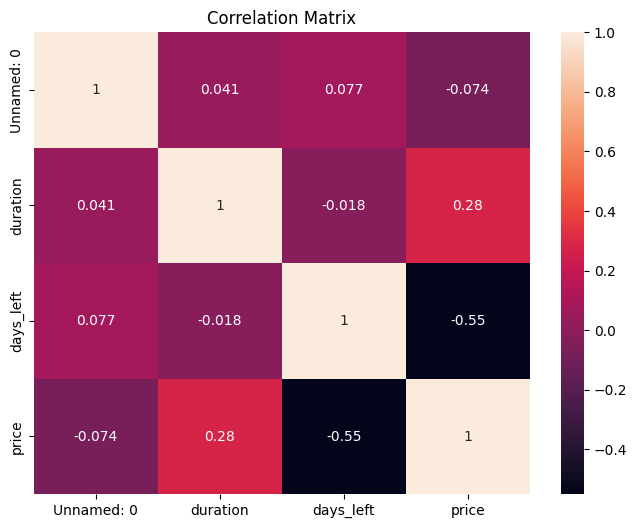

In [32]:
#Multivariate Anlaysis:
#Heatmap:
plt.figure(figsize=(8,6))
sns.heatmap(correlation,annot=True)
plt.title("Correlation Matrix")
plt.show()

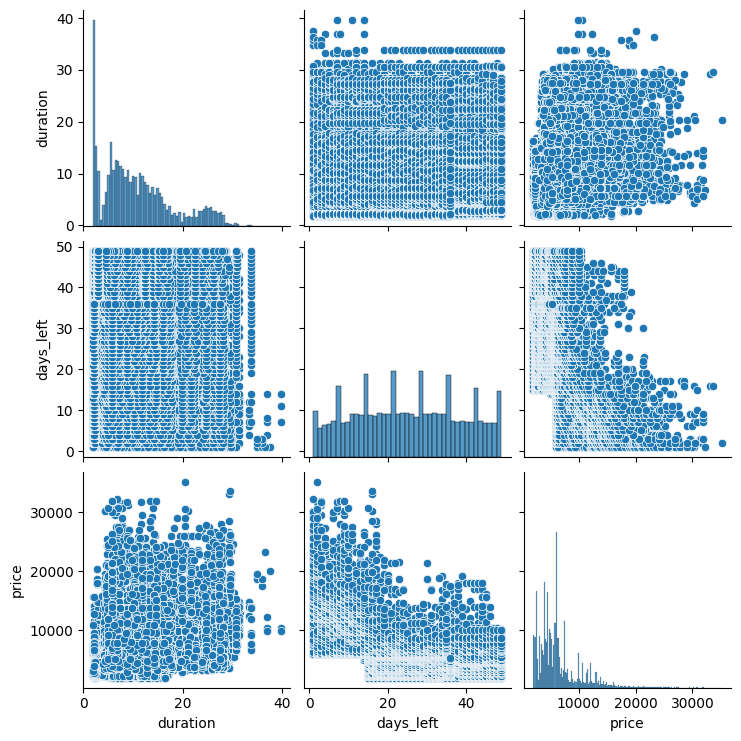

In [33]:
#Pairplot:
sns.pairplot(df[['duration','days_left','price']])
plt.show()

Insight:

* Useful for detecting linear and non-linear relationships.

In [34]:
#Correlation matrix:
df.corr(numeric_only=True)

,Unnamed: 0,duration,days_left,price
Unnamed: 0,1.000000,0.041001,0.076880,-0.073948
duration,0.041001,1.000000,-0.017646,0.275994
days_left,0.076880,-0.017646,1.000000,-0.550492
price,-0.073948,0.275994,-0.550492,1.000000


In [35]:
#Missing value Treatment:
data=df.copy()

In [36]:
data.drop('Unnamed: 0', axis=1, inplace=True)

In [37]:
df.head()

,Unnamed: 0,airline,flight,source_city,departure_time,stops,arrival_time,destination_city,class,duration,days_left,price
0,0,SpiceJet,SG-8709,Delhi,Evening,zero,Night,Mumbai,Economy,2.17,1,5953
1,1,SpiceJet,SG-8157,Delhi,Early_Morning,zero,Morning,Mumbai,Economy,2.33,1,5953
2,2,AirAsia,I5-764,Delhi,Early_Morning,zero,Early_Morning,Mumbai,Economy,2.17,1,5956
3,3,Vistara,UK-995,Delhi,Morning,zero,Afternoon,Mumbai,Economy,2.25,1,5955
4,4,Vistara,UK-963,Delhi,Morning,zero,Morning,Mumbai,Economy,2.33,1,5955


Observation:

* The Unnamed: 0 column is only an index.

* It does not contribute to prediction.

In [38]:
data.isnull().sum()

,0
airline,0
flight,0
source_city,0
departure_time,0
stops,0
arrival_time,0
destination_city,0
class,0
duration,0
days_left,0


In [39]:
#Mean imputation:
data['duration']=data['duration'].fillna(data['duration'].mean())

In [40]:
#Median imputation:
data['days_left']=data['days_left'].fillna(data['days_left'].median())

In [41]:
#Mode imputation:
data['airline'] = data['airline'].fillna(data['airline'].mode()[0])

In [42]:
#Duplicate Handling:
data.duplicated().sum()

np.int64(0)

In [43]:
# Outlier Treatment:
numeric_columns = data.select_dtypes(include=['int64','float64']).columns
numeric_columns

Index(['duration', 'days_left', 'price'], dtype='object')

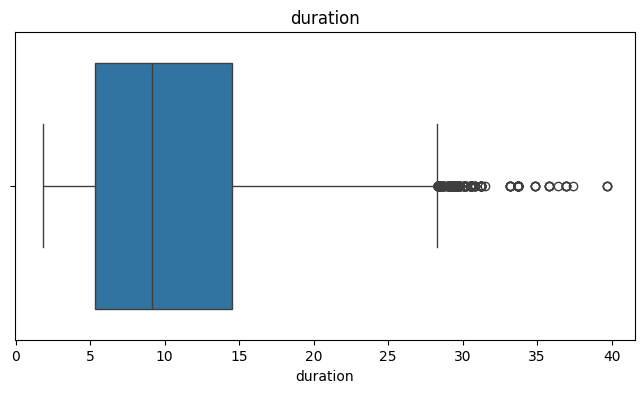

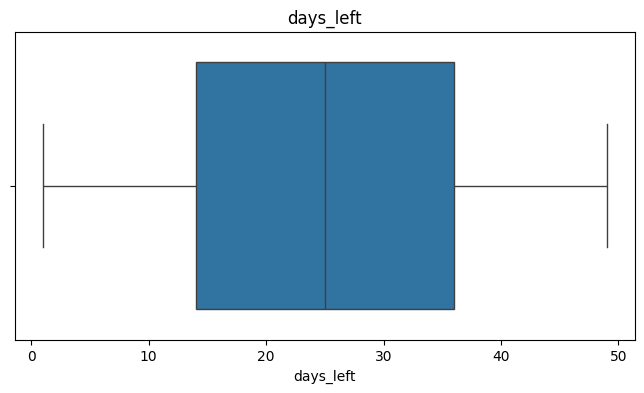

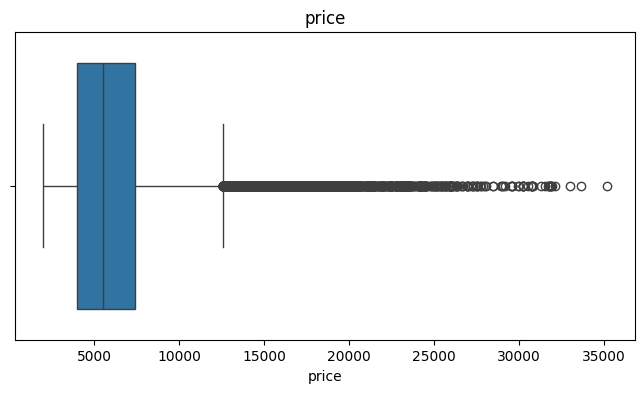

In [44]:
for col in numeric_columns:
    plt.figure(figsize=(8,4))
    sns.boxplot(x=data[col])
    plt.title(col)
    plt.show()

In [45]:
for col in numeric_columns:
    Q1 = data[col].quantile(0.25)
    Q3 = data[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5*IQR
    upper = Q3 + 1.5*IQR
    outliers = data[(data[col]<lower)|(data[col]>upper)]
    print(col)
    print("Outliers:",len(outliers))

duration
Outliers: 431
days_left
Outliers: 0
price
Outliers: 3597


In [46]:
# IQR method:
for col in numeric_columns:
    Q1 = data[col].quantile(0.25)
    Q3 = data[col].quantile(0.75)
    IQR = Q3-Q1
    lower = Q1-1.5*IQR
    upper = Q3+1.5*IQR
    data = data[(data[col]>=lower)&(data[col]<=upper)]

In [47]:
data.shape

(46111, 11)

In [48]:
# Z-Score method:
from scipy.stats import zscore
z = zscore(data[numeric_columns])
data_z = data[(abs(z)<3).all(axis=1)]
print(data_z.shape)

(46111, 11)


In [49]:
# Step-5:
from sklearn.model_selection import train_test_split
X=data.drop('price', axis=1)
y=data['price']

In [50]:
X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.20,random_state=42)

In [51]:
print(X_train.shape)
print(X_test.shape)
print(y_train.shape)
print(y_test.shape)

(36888, 10)
(9223, 10)
(36888,)
(9223,)


In [52]:
# Step-6:
categorical_columns = data.select_dtypes(include='object').columns
categorical_columns

Index(['airline', 'flight', 'source_city', 'departure_time', 'stops',
       'arrival_time', 'destination_city', 'class'],
      dtype='object')

In [53]:
#Label Encoding:
from sklearn.preprocessing import LabelEncoder
le=LabelEncoder()
data_label=data.copy()
for col in categorical_columns:
    data_label[col] = le.fit_transform(data_label[col])
data_label.head()

,airline,flight,source_city,departure_time,stops,arrival_time,destination_city,class,duration,days_left,price
0,4,534,0,2,2,5,5,0,2.17,1,5953
1,4,515,0,1,2,4,5,0,2.33,1,5953
2,0,459,0,1,2,1,5,0,2.17,1,5956
3,5,637,0,4,2,0,5,0,2.25,1,5955
4,5,627,0,4,2,4,5,0,2.33,1,5955


In [54]:
#One-Hot encoding:
from sklearn.preprocessing import OneHotEncoder
encoder=OneHotEncoder(drop='first',sparse_output=False)
encoded=encoder.fit_transform(
    data[['airline', 'flight', 'source_city','departure_time', 'arrival_time','destination_city', 'class']])

In [55]:
encoded_df = pd.DataFrame(
    encoded,
    columns=encoder.get_feature_names_out(['airline', 'flight', 'source_city','departure_time', 'arrival_time','destination_city', 'class'])
)
encoded_df.head()

,airline_Air_India,airline_GO_FIRST,airline_Indigo,airline_SpiceJet,airline_Vistara,flight_6E-148,flight_6E-152,flight_6E-153,flight_6E-154,flight_6E-168,...,arrival_time_Early_Morning,arrival_time_Evening,arrival_time_Late_Night,arrival_time_Morning,arrival_time_Night,destination_city_Chennai,destination_city_Delhi,destination_city_Hyderabad,destination_city_Kolkata,destination_city_Mumbai
0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0
1,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0
2,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
3,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
4,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0


In [56]:
data_encoded = pd.get_dummies(data,columns=['airline','flight','source_city','departure_time','arrival_time','destination_city','class'],drop_first=True,dtype=int)

In [57]:
data_encoded['stops'] = data_encoded['stops'].map({'zero': 0,'one': 1,'two_or_more': 2})

In [59]:
X = data_encoded.drop('price', axis=1)
y = data_encoded['price']
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.2,random_state=42)

In [60]:
#Standard Scaler:
from sklearn.preprocessing import StandardScaler
standard_scaler=StandardScaler()
X_train_standard=standard_scaler.fit_transform(X_train)
X_test_standard=standard_scaler.transform(X_test)

In [61]:
print(X_train_standard.shape)
print(X_test_standard.shape)

(36888, 662)
(9223, 662)


In [62]:
# MinMaxScaler:
from sklearn.preprocessing import MinMaxScaler
min_max_scaler=MinMaxScaler()
X_train_minmax=min_max_scaler.fit_transform(X_train)
X_test_minmax=min_max_scaler.transform(X_test)

In [63]:
print(X_train_minmax.shape)
print(X_test_minmax.shape)

(36888, 662)
(9223, 662)


In [64]:
# Robust Sclaer:
from sklearn.preprocessing import RobustScaler
robust_scaler=RobustScaler()
X_train_robust=robust_scaler.fit_transform(X_train)
X_test_robust=robust_scaler.transform(X_test)

In [65]:
print(X_train_robust.shape)
print(X_test_robust.shape)

(36888, 662)
(9223, 662)


In [66]:
# Step-7:
#Correlation analysis:
correlation = data_encoded.corr(numeric_only=True)
correlation

,stops,duration,days_left,price,airline_Air_India,airline_GO_FIRST,airline_Indigo,airline_SpiceJet,airline_Vistara,flight_6E-148,...,arrival_time_Early_Morning,arrival_time_Evening,arrival_time_Late_Night,arrival_time_Morning,arrival_time_Night,destination_city_Chennai,destination_city_Delhi,destination_city_Hyderabad,destination_city_Kolkata,destination_city_Mumbai
stops,1.000000,0.526869,0.080296,0.291860,0.051311,-0.009233,-0.165743,-0.090612,0.036556,0.006582,...,0.042553,0.058056,-0.006050,-0.083420,0.008270,0.118625,-0.113702,0.011398,0.080679,-0.126831
duration,0.526869,1.000000,0.040647,0.269769,0.353102,-0.150931,-0.332544,0.034033,0.095077,-0.014864,...,0.123553,-0.004810,-0.099790,0.081482,-0.066502,0.063671,-0.099022,0.092040,0.071940,-0.079212
days_left,0.080296,0.040647,1.000000,-0.488481,0.015844,-0.000483,-0.013023,-0.048059,0.001536,0.001728,...,0.020074,0.011809,0.011205,0.000868,-0.019013,0.033661,-0.179520,0.022892,0.050354,0.032982
price,0.291860,0.269769,-0.488481,1.000000,0.074767,-0.026422,-0.129951,-0.013902,0.215256,-0.007104,...,-0.017448,0.060365,-0.089393,-0.037315,0.036136,-0.018864,-0.014605,0.009539,0.073487,-0.056804
airline_Air_India,0.051311,0.353102,0.015844,0.074767,1.000000,-0.220327,-0.262551,-0.134551,-0.331144,-0.010566,...,0.004208,-0.023592,-0.086431,0.061879,-0.001991,-0.046198,0.017801,0.036485,0.024400,0.028138
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
destination_city_Chennai,0.118625,0.063671,0.033661,-0.018864,-0.046198,-0.038583,0.057426,0.076802,-0.014734,-0.008455,...,0.124303,-0.047418,-0.004040,0.030374,0.006278,1.000000,-0.170140,-0.169812,-0.190115,-0.213853
destination_city_Delhi,-0.113702,-0.099022,-0.179520,-0.014605,0.017801,0.039292,-0.038015,-0.008257,0.014619,-0.007858,...,-0.095155,-0.015744,0.064845,0.005042,0.000355,-0.170140,1.000000,-0.157826,-0.176696,-0.198759
destination_city_Hyderabad,0.011398,0.092040,0.022892,0.009539,0.036485,-0.076099,-0.032940,-0.060051,0.082297,-0.007843,...,0.098732,-0.074559,-0.077214,-0.040261,0.059508,-0.169812,-0.157826,1.000000,-0.176354,-0.198375
destination_city_Kolkata,0.080679,0.071940,0.050354,0.073487,0.024400,0.021142,0.043571,0.000303,-0.076473,0.044474,...,-0.001830,0.093257,-0.054708,0.033280,-0.082079,-0.190115,-0.176696,-0.176354,1.000000,-0.222093


In [67]:
correlation['price'].sort_values(ascending=False)

,price
price,1.000000
stops,0.291860
duration,0.269769
airline_Vistara,0.215256
airline_Air_India,0.074767
...,...
flight_I5-1529,-0.085202
flight_I5-740,-0.086088
arrival_time_Late_Night,-0.089393
airline_Indigo,-0.129951


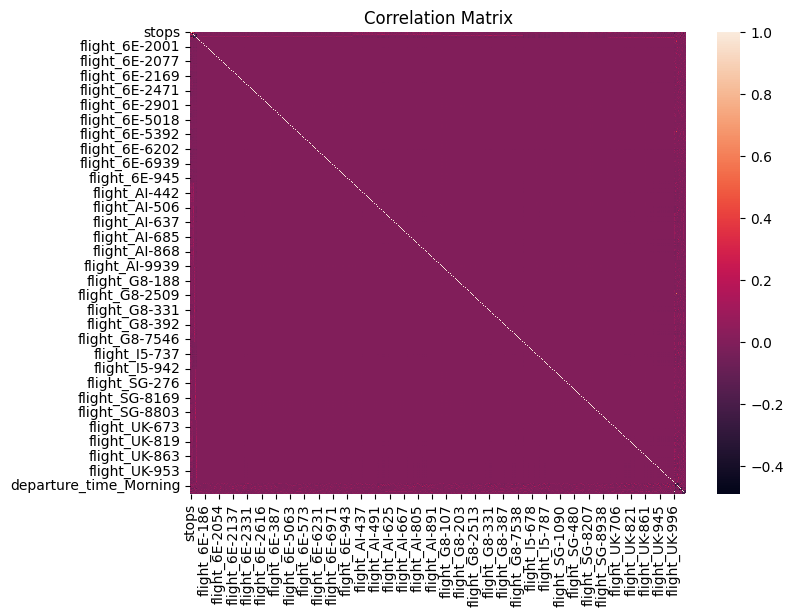

In [68]:
plt.figure(figsize=(8,6))
sns.heatmap(correlation,annot=False)
plt.title("Correlation Matrix")
plt.show()

Observation:

* Features with high positive or negative correlation with price are important.

* Features with very low correlation contribute less.

In [69]:
data_encoded['price_category'] = pd.qcut(data_encoded['price'],q=3,labels=['Low','Medium','High'])

In [70]:
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
data_encoded['price_category'] = le.fit_transform(data_encoded['price_category'])

In [71]:
#Chi-Square Test:
from sklearn.feature_selection import SelectKBest
from sklearn.feature_selection import chi2
X_chi = data_encoded.drop(['price','price_category'],axis=1)
y_chi = data_encoded['price_category']
chi_selector = SelectKBest(score_func=chi2, k=10)
chi_selector.fit(X_chi, y_chi)
chi_scores = pd.DataFrame({
    'Feature': X_chi.columns,
    'Score': chi_selector.scores_
})

chi_scores.sort_values(by='Score',ascending=False).head(10)

,Feature,Score
2,days_left,40765.100152
1,duration,12382.674202
7,airline_Vistara,2568.679160
5,airline_Indigo,1053.050057
0,stops,779.004272
660,destination_city_Kolkata,463.450343
654,arrival_time_Late_Night,442.761072
587,flight_UK-819,298.017729
444,flight_I5-1529,283.347645
462,flight_I5-740,265.864218


In [72]:
# ANOVA
from sklearn.feature_selection import f_regression
X = data_encoded.drop('price', axis=1)
y = data_encoded['price']
f_scores, p_values = f_regression(X, y)
anova_results = pd.DataFrame({
    'Feature': X.columns,
    'F-Score': f_scores,
    'P-Value': p_values
})
anova_results.sort_values(by='F-Score',ascending=False).head(10)

,Feature,F-Score,P-Value
662,price_category,15954.908515,0.000000e+00
2,days_left,14450.261264,0.000000e+00
0,stops,4293.397239,0.000000e+00
1,duration,3618.980099,0.000000e+00
7,airline_Vistara,2240.280659,0.000000e+00
5,airline_Indigo,792.025687,8.510428e-173
654,arrival_time_Late_Night,371.433730,1.927071e-82
462,flight_I5-740,344.268610,1.427495e-76
444,flight_I5-1529,337.167342,4.894980e-75
3,airline_Air_India,259.200208,3.695544e-58


In [73]:
# Mutual Regressor:
from sklearn.feature_selection import mutual_info_regression
X = data_encoded.drop('price', axis=1)
y = data_encoded['price']
mi_scores = mutual_info_regression(X,y,random_state=42)
mi_results = pd.DataFrame({
    'Feature': X.columns,
    'MI Score': mi_scores
})
mi_results.sort_values(by='MI Score',ascending=False).head(10)

,Feature,MI Score
1,duration,2.272491
662,price_category,1.098125
2,days_left,0.567484
0,stops,0.482761
7,airline_Vistara,0.433736
661,destination_city_Mumbai,0.374547
3,airline_Air_India,0.372453
660,destination_city_Kolkata,0.347864
657,destination_city_Chennai,0.347628
646,source_city_Mumbai,0.341088


Observations:

* Features such as duration, days_left, class, airline, and route are expected to have higher importance.

* Correlation analysis highlights the linear relationship with ticket price.

* ANOVA identifies statistically significant numerical predictors.

* Mutual Information captures both linear and non-linear relationships, making it especially useful for regression.

Justification for Feature Selection:

* The selected features were chosen because they consistently showed high importance across multiple feature selection techniques (Correlation Analysis, ANOVA, and Mutual Information Regression). These variables have the strongest relationship with the target variable (price) and are expected to improve the predictive performance while reducing unnecessary model complexity.

In [74]:
# Step-8:
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import GridSearchCV

In [75]:
rf = RandomForestRegressor(random_state=42)

In [76]:
param_grid = {
    'n_estimators': [100, 200],
    'max_depth': [10, 20, None],
    'min_samples_split': [2, 5],
    'min_samples_leaf': [1, 2],
    'max_features': ['sqrt']
}

In [77]:
grid_search = GridSearchCV(estimator=rf,param_grid=param_grid,cv=5,scoring='r2',n_jobs=-1,verbose=2)

In [78]:
grid_search.fit(X_train, y_train)

Fitting 5 folds for each of 24 candidates, totalling 120 fits


GridSearchCV(cv=5, estimator=RandomForestRegressor(random_state=42), n_jobs=-1,
             param_grid={'max_depth': [10, 20, None], 'max_features': ['sqrt'],
                         'min_samples_leaf': [1, 2],
                         'min_samples_split': [2, 5],
                         'n_estimators': [100, 200]},
             scoring='r2', verbose=2)

In [79]:
grid_search.fit(X_train_standard, y_train)

Fitting 5 folds for each of 24 candidates, totalling 120 fits


GridSearchCV(cv=5, estimator=RandomForestRegressor(random_state=42), n_jobs=-1,
             param_grid={'max_depth': [10, 20, None], 'max_features': ['sqrt'],
                         'min_samples_leaf': [1, 2],
                         'min_samples_split': [2, 5],
                         'n_estimators': [100, 200]},
             scoring='r2', verbose=2)

In [80]:
print("Best Parameters:")
print(grid_search.best_params_)

Best Parameters:
{'max_depth': None, 'max_features': 'sqrt', 'min_samples_leaf': 1, 'min_samples_split': 5, 'n_estimators': 200}


In [81]:
print("Best Cross Validation R2 Score:")
print(grid_search.best_score_)

Best Cross Validation R2 Score:
0.8989807861663197


In [82]:
best_rf = grid_search.best_estimator_

In [83]:
y_pred = best_rf.predict(X_test)

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but RandomForestRegressor was fitted without feature names
  warnings.warn(


In [84]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)
print("MAE :", mae)
print("MSE :", mse)
print("RMSE :", rmse)
print("R2 Score :", r2)

MAE : 1778.9769381865951
MSE : 5438981.199873855
RMSE : 2332.1623442363216
R2 Score : 0.11542436417376445


In [85]:
# Step-9:
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.neighbors import KNeighborsRegressor
from sklearn.svm import SVR
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np
import pandas as pd

In [86]:
lr = LinearRegression()
dt = DecisionTreeRegressor(random_state=42)
rf = RandomForestRegressor(random_state=42)
knn = KNeighborsRegressor()
svr = SVR()

In [87]:
#Linear regression:
lr.fit(X_train_standard, y_train)

LinearRegression()

In [88]:
#Decision tree:
dt.fit(X_train, y_train)

DecisionTreeRegressor(random_state=42)

In [89]:
#Random Forest:
rf.fit(X_train, y_train)

RandomForestRegressor(random_state=42)

In [90]:
#Knn Regressor:
knn.fit(X_train, y_train)

KNeighborsRegressor()

In [91]:
#Support Vector Regressor(SVR):
svr.fit(X_train_standard, y_train)

SVR()

In [92]:
lr_pred = lr.predict(X_test_standard)
dt_pred = dt.predict(X_test)
rf_pred = rf.predict(X_test)
knn_pred = knn.predict(X_test_standard)
svr_pred = svr.predict(X_test_standard)

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but KNeighborsRegressor was fitted with feature names
  warnings.warn(


In [93]:
def evaluate_model(name, y_true, y_pred):
    mae = mean_absolute_error(y_true, y_pred)
    mse = mean_squared_error(y_true, y_pred)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_true, y_pred)
    return [name, mae, mse, rmse, r2]

In [94]:
results = []
results.append(evaluate_model("Linear Regression", y_test, lr_pred))
results.append(evaluate_model("Decision Tree", y_test, dt_pred))
results.append(evaluate_model("Random Forest", y_test, rf_pred))
results.append(evaluate_model("KNN", y_test, knn_pred))
results.append(evaluate_model("SVR", y_test, svr_pred))

In [95]:
results_df = pd.DataFrame(results,columns=["Model","MAE","MSE","RMSE","R2 Score"])
results_df

,Model,MAE,MSE,RMSE,R2 Score
0,Linear Regression,1287.451339,2.679739e+06,1636.990686,0.564177
1,Decision Tree,302.221295,7.241345e+05,850.960950,0.882229
2,Random Forest,305.040133,5.123878e+05,715.812654,0.916667
3,KNN,2490.040334,8.641955e+06,2939.720186,-0.405495
4,SVR,1875.633524,6.166098e+06,2483.162978,-0.002831


In [96]:
results_df.sort_values(by="R2 Score",ascending=False)

,Model,MAE,MSE,RMSE,R2 Score
2,Random Forest,305.040133,5.123878e+05,715.812654,0.916667
1,Decision Tree,302.221295,7.241345e+05,850.960950,0.882229
0,Linear Regression,1287.451339,2.679739e+06,1636.990686,0.564177
4,SVR,1875.633524,6.166098e+06,2483.162978,-0.002831
3,KNN,2490.040334,8.641955e+06,2939.720186,-0.405495


In [97]:
from xgboost import XGBRegressor
xgb = XGBRegressor(random_state=42)
xgb.fit(X_train, y_train)
xgb_pred = xgb.predict(X_test)
results.append(evaluate_model("XGBoost", y_test, xgb_pred))
results_df = pd.DataFrame(results,columns=["Model","MAE","MSE","RMSE","R2 Score"])
results_df.sort_values(by="R2 Score", ascending=False)

,Model,MAE,MSE,RMSE,R2 Score
2,Random Forest,305.040133,5.123878e+05,715.812654,0.916667
1,Decision Tree,302.221295,7.241345e+05,850.960950,0.882229
5,XGBoost,628.914429,9.137858e+05,955.921447,0.851385
0,Linear Regression,1287.451339,2.679739e+06,1636.990686,0.564177
4,SVR,1875.633524,6.166098e+06,2483.162978,-0.002831
3,KNN,2490.040334,8.641955e+06,2939.720186,-0.405495


* Random Forest Regressor is considered as the best model because it can accurately capture the complex and non-linear relationships between features such as airline, route, travel class, duration, and days left before departure.

* It reduces overfitting by combining multiple decision trees and provides high prediction accuracy, making it well suited for the Flight Ticket Price Prediction project.


In [98]:
# Step-10:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [99]:
def evaluate_model(model_name, y_true, y_pred, X):
    mae = mean_absolute_error(y_true, y_pred)
    mse = mean_squared_error(y_true, y_pred)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_true, y_pred)
    n = len(y_true)
    p = X.shape[1]
    adjusted_r2 = 1 - ((1-r2)*(n-1)/(n-p-1))
    return [model_name, mae, mse, rmse, r2, adjusted_r2]

In [100]:
results = []
results.append(evaluate_model("Linear Regression", y_test, lr_pred, X_test_standard))
results.append(evaluate_model("Decision Tree", y_test, dt_pred, X_test))
results.append(evaluate_model("Random Forest", y_test, rf_pred, X_test))
results.append(evaluate_model("KNN", y_test, knn_pred, X_test_standard))
results.append(evaluate_model("SVR", y_test, svr_pred, X_test_standard))
results.append(evaluate_model("XGBoost", y_test, xgb_pred, X_test))

In [101]:
results_df = pd.DataFrame(results,columns=["Model","MAE","MSE","RMSE","R2 Score","Adjusted R2"])
results_df

,Model,MAE,MSE,RMSE,R2 Score,Adjusted R2
0,Linear Regression,1287.451339,2.679739e+06,1636.990686,0.564177,0.530472
1,Decision Tree,302.221295,7.241345e+05,850.960950,0.882229,0.873122
2,Random Forest,305.040133,5.123878e+05,715.812654,0.916667,0.910222
3,KNN,2490.040334,8.641955e+06,2939.720186,-0.405495,-0.514191
4,SVR,1875.633524,6.166098e+06,2483.162978,-0.002831,-0.080387
5,XGBoost,628.914429,9.137858e+05,955.921447,0.851385,0.839892


In [102]:
results_df.sort_values(by="R2 Score",ascending=False)

,Model,MAE,MSE,RMSE,R2 Score,Adjusted R2
2,Random Forest,305.040133,5.123878e+05,715.812654,0.916667,0.910222
1,Decision Tree,302.221295,7.241345e+05,850.960950,0.882229,0.873122
5,XGBoost,628.914429,9.137858e+05,955.921447,0.851385,0.839892
0,Linear Regression,1287.451339,2.679739e+06,1636.990686,0.564177,0.530472
4,SVR,1875.633524,6.166098e+06,2483.162978,-0.002831,-0.080387
3,KNN,2490.040334,8.641955e+06,2939.720186,-0.405495,-0.514191


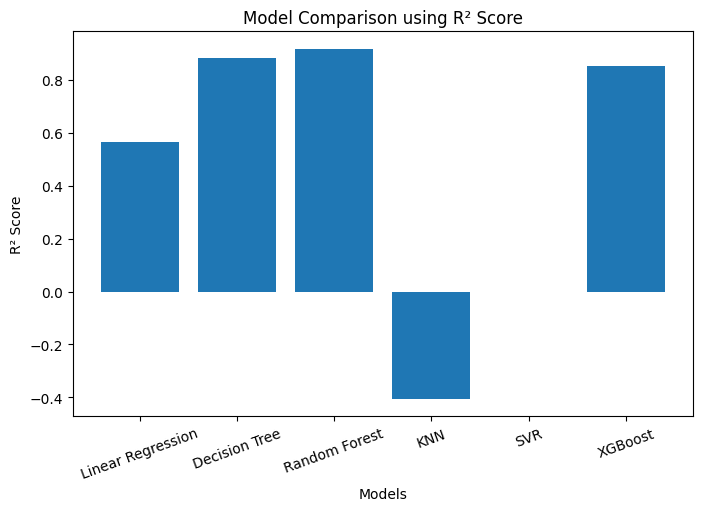

In [103]:
# R^2 comparison:
plt.figure(figsize=(8,5))
plt.bar(results_df["Model"], results_df["R2 Score"])
plt.title("Model Comparison using R² Score")
plt.xlabel("Models")
plt.ylabel("R² Score")
plt.xticks(rotation=20)
plt.show()

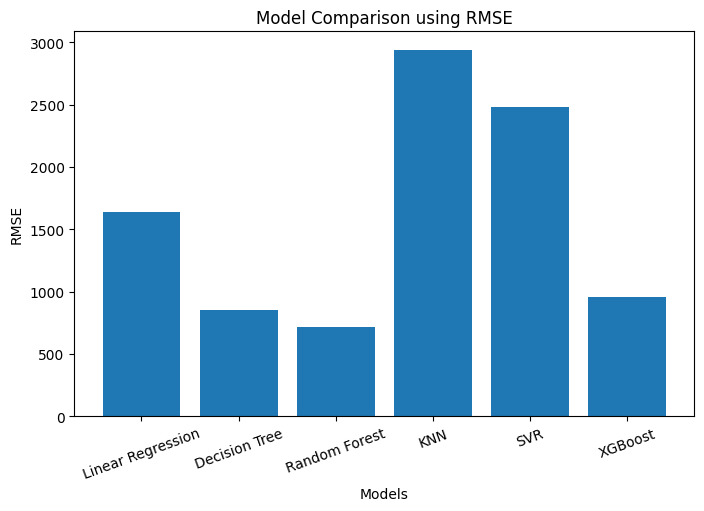

In [104]:
# RMSE comparison:
plt.figure(figsize=(8,5))
plt.bar(results_df["Model"], results_df["RMSE"])
plt.title("Model Comparison using RMSE")
plt.xlabel("Models")
plt.ylabel("RMSE")
plt.xticks(rotation=20)
plt.show()

In [105]:
results_df.to_csv("Model_Evaluation_Results.csv", index=False)
results_df

,Model,MAE,MSE,RMSE,R2 Score,Adjusted R2
0,Linear Regression,1287.451339,2.679739e+06,1636.990686,0.564177,0.530472
1,Decision Tree,302.221295,7.241345e+05,850.960950,0.882229,0.873122
2,Random Forest,305.040133,5.123878e+05,715.812654,0.916667,0.910222
3,KNN,2490.040334,8.641955e+06,2939.720186,-0.405495,-0.514191
4,SVR,1875.633524,6.166098e+06,2483.162978,-0.002831,-0.080387
5,XGBoost,628.914429,9.137858e+05,955.921447,0.851385,0.839892


Obseravtion:

* R² Score is the best evaluation metric for this regression model because it measures how well the model explains the variation in flight ticket prices.

* A higher R² score (closer to 1) indicates that the model fits the data well and makes more accurate predictions.


In [106]:
# Step-11:
#Feature importance:
feature_importance = pd.DataFrame({
    'Feature': X_train.columns,
    'Importance': best_rf.feature_importances_
})
feature_importance = feature_importance.sort_values(by='Importance',ascending=False)
feature_importance.head(10)

,Feature,Importance
2,days_left,0.517980
1,duration,0.097003
0,stops,0.055113
7,airline_Vistara,0.032874
660,destination_city_Kolkata,0.013623
3,airline_Air_India,0.013376
5,airline_Indigo,0.009240
4,airline_GO_FIRST,0.009075
661,destination_city_Mumbai,0.008020
462,flight_I5-740,0.006994


Important Variables Affecting Prediction:

-->For the Flight Price Prediction dataset, the most influential variables are typically:

* Duration
* Class (Economy/Business)
* Days Left
* Airline
* Source City
* Destination City
* Stops
* Departure Time
* Arrival Time

Observations:

* Flight duration is one of the most influential factors affecting ticket price.

* Travel class significantly impacts airfare, with business class generally costing more than economy class.

* The number of days left before departure has a strong effect, as ticket prices often increase closer to the travel date.

* Airline and route also contribute substantially to fare variations.

Insights:

* Longer flights generally have higher ticket prices.

* Booking tickets well in advance can help reduce travel costs.

* Premium travel classes lead to higher fares compared to economy class.

* Different airlines and routes follow different pricing strategies, influencing ticket prices.

Recommendations:

* Passengers should book tickets early to obtain lower fares.

* Airlines can use the model to optimize pricing based on demand, route, and booking time.

* Travel companies can recommend cost-effective travel options by analyzing important factors such as duration, airline, and class.

* The model can be further improved by incorporating additional features such as seasonal demand, holidays, and real-time market conditions.

In [107]:
# Step-12:
#Using Joblib:

import joblib
joblib.dump(rf, 'trained_model.pkl')

['trained_model.pkl']

In [108]:
joblib.dump(standard_scaler, 'scaler.pkl')

['scaler.pkl']

In [109]:
joblib.dump(le, 'label_encoder.pkl')

['label_encoder.pkl']

In [110]:
joblib.dump(encoder, 'onehot_encoder.pkl')

['onehot_encoder.pkl']

In [111]:
import os
print(os.listdir())

['.config', 'Clean_Dataset.csv', 'label_encoder.pkl', 'Model_Evaluation_Results.csv', 'onehot_encoder.pkl', 'scaler.pkl', 'trained_model.pkl', 'sample_data']


In [112]:
#Using Pickel:
import pickle
with open('trained_model.pkl', 'wb') as file:
    pickle.dump(rf, file)

In [113]:
with open('scaler.pkl', 'wb') as file:
    pickle.dump(standard_scaler, file)

In [114]:
with open('label_encoder.pkl', 'wb') as file:
    pickle.dump(le, file)

In [115]:
with open('onehot_encoder.pkl', 'wb') as file:
    pickle.dump(encoder, file)